In [ ]:
!mkdir -p ~/.kaggle

In [ ]:
!cp kaggle.json ~/.kaggle/

In [ ]:
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d msambare/fer2013

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
  0% 0.00/60.3M [00:00<?, ?B/s]
100% 60.3M/60.3M [00:00<00:00, 1.71GB/s]


In [ ]:
!unzip fer2013.zip

Streaming output truncated to the last 5000 lines.
  inflating: train/sad/Training_65242339.jpg  
  inflating: train/sad/Training_65267116.jpg  
  inflating: train/sad/Training_65275626.jpg  
  inflating: train/sad/Training_6529266.jpg  
  inflating: train/sad/Training_65329617.jpg  
  inflating: train/sad/Training_65338712.jpg  
  inflating: train/sad/Training_65338797.jpg  
  inflating: train/sad/Training_65387162.jpg  
  inflating: train/sad/Training_65404494.jpg  
  inflating: train/sad/Training_65426218.jpg  
  inflating: train/sad/Training_65430136.jpg  
  inflating: train/sad/Training_65437377.jpg  
  inflating: train/sad/Training_6545735.jpg  
  inflating: train/sad/Training_65463385.jpg  
  inflating: train/sad/Training_65473985.jpg  
  inflating: train/sad/Training_65502829.jpg  
  inflating: train/sad/Training_65505359.jpg  
  inflating: train/sad/Training_65508578.jpg  
  inflating: train/sad/Training_65516023.jpg  
  inflating: train/sad/Training_65524027.jpg  
  inflating

In [ ]:
import tensorflow as tf

tf.config.list_physical_devices('GPU')


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import imghdr
import tensorflow as tf
from PIL import Image
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report, roc_curve ,auc
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras import layers,models,regularizers,optimizers
from tensorflow.keras.applications import VGG16, ResNet50V2
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, TensorBoard, CSVLogger
from tensorflow.keras.layers import Conv2D,MaxPooling2D,BatchNormalization,Dropout,Flatten,Dense,Activation,GlobalAveragePooling2D
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.optimizers import Adam,Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from keras.utils import plot_model

/tmp/ipython-input-944180980.py:7: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


In [ ]:
project_name = 'Emotion Detection'
model_names = [
    'ResNet50V2_Transfer_Learning'
]

base_dir = '/content/'

project_dir = os.path.join(base_dir, project_name)
os.makedirs(project_dir, exist_ok=True)

for each_model in model_names:
    model_dir = os.path.join(project_dir, each_model)
    os.makedirs(model_dir, exist_ok=True)

In [ ]:
image_exts = ['jpeg','jpg','png']

data_dir = '/content/train'

for root,dirs,files in os.walk(data_dir):
  for file in files:

    file_path = os.path.join(root,file)

    try:
      file_type = imghdr.what(file_path)

      if file_type not in image_exts:
        print(f'image not in ext list {file_path}')
        os.remove(file_path)

      else:

        img = cv2.imread(file_path)

    except Exception as e:

      print(f'issue with the file {file_path}.Error:{e}')

      os.remove(file_path)

In [ ]:
def count_files_in_subdirs(directory,set_name):

  counts = {}

  for item in os.listdir(directory):

    item_path = os.path.join(directory,item)

    if os.path.isdir(item_path):

      counts[item] = len(os.listdir(item_path))

  df = pd.DataFrame(counts,index =[set_name])

  return df


train_dr = '/content/train'
test_dr = '/content/test'

train_count = count_files_in_subdirs(train_dr,'train')
print(train_count)

test_count = count_files_in_subdirs(test_dr,'test')
print(test_count)

       happy  surprise  angry  disgust  neutral  fear   sad
train   7215      3171   3995      436     4965  4097  4830
      happy  surprise  angry  disgust  neutral  fear   sad
test   1774       831    958      111     1233  1024  1247


<Axes: >

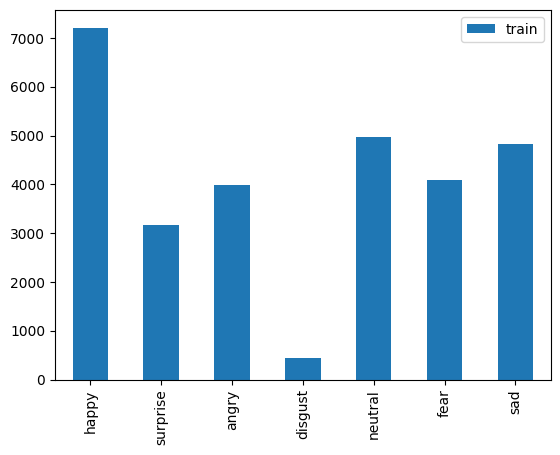

In [ ]:
train_count.transpose().plot(kind='bar')

<Axes: >

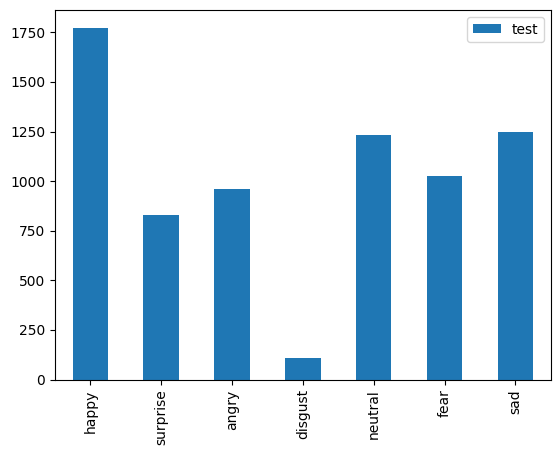

In [ ]:
test_count.transpose().plot(kind='bar')

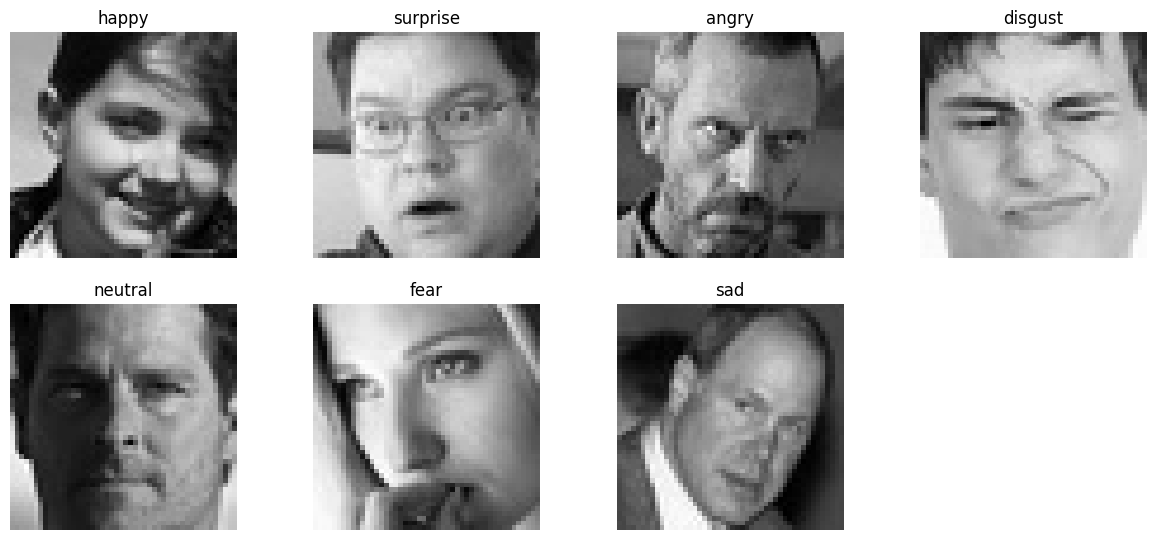

In [ ]:
emotions = os.listdir(train_dr)
plt.figure(figsize=(15,10))

for i,emotion in enumerate(emotions,1):

  folder = os.path.join(train_dr,emotion)
  img_path = os.path.join(folder,os.listdir(folder)[42])
  img = plt.imread(img_path)
  plt.subplot(3,4,i)
  plt.imshow(img,cmap='gray')
  plt.title(emotion)
  plt.axis('off')

In [ ]:
def plot_images_from_directory(directory_path,class_name,num_images=9):

  image_filenames = os.listdir(directory_path)

  if len(image_filenames) < num_images:
    print(f'only found {len(image_filenames)} images in {directory_path},displaying them all')
    num_images = len(image_filenames)

  selected_images = random.sample(image_filenames,num_images)

  fig,axes = plt.subplots(3,3,figsize=(5,5))
  axes = axes.ravel()

  for i,image_file in enumerate(selected_images):
    image_path = os.path.join(directory_path,image_file)

    image = load_img(image_path)
    axes[i].imshow(image)
    axes[i].set_title(class_name)
    axes[i].axis('off')

  plt.tight_layout()
  plt.show()

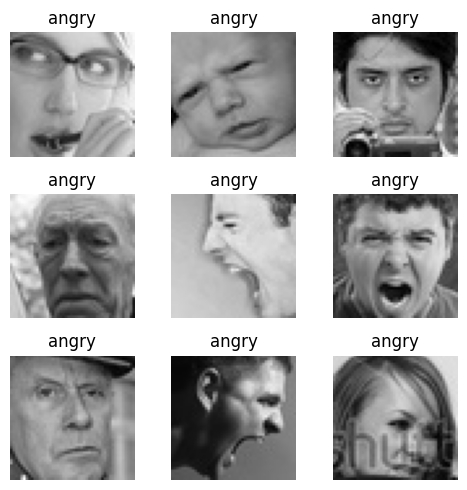

In [ ]:
angry_directory_path = '/content/train/angry'
plot_images_from_directory(angry_directory_path,class_name='angry')

In [ ]:
image = '/content/test/angry/PrivateTest_10131363.jpg'
img = cv2.imread(image)

if img is not None:
  print("shape: ",img.shape)

else:
  print('image could not be loaded')

shape:  (48, 48, 3)


In [ ]:
image = '/content/test/angry/PrivateTest_10131363.jpg'
img = cv2.imread(image,cv2.IMREAD_GRAYSCALE)

if img is not None:
  print("shape: ",img.shape)

else:
  print('image could not be loaded')

shape:  (48, 48)


In [ ]:
train_data_dir = '/content/train'
test_data_dir = '/content/test'

In [ ]:
img_width,img_height = 224,224
batch_size=64
epochs=10
num_classes=7

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    color_mode='rgb',
    subset='training',
    shuffle=True
)


# validation_generator = val_datagen.flow_from_directory(
#     train_data_dir,
#     target_size=(img_width, img_height),
#     batch_size=batch_size,
#     class_mode='categorical',
#     color_mode='grayscale',
#     subset='validation',
#     shuffle=False
# )


test_generator = test_datagen.flow_from_directory(
    test_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [ ]:
classes = np.array(train_generator.classes)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes = np.unique(classes),
    y=classes
)

class_weights_dict = dict(enumerate(class_weights))

print('class weights dictionary: ',class_weights_dict)

class weights dictionary:  {0: np.float64(1.0266046844269623), 1: np.float64(9.406618610747051), 2: np.float64(1.0010460615781582), 3: np.float64(0.5684387684387684), 4: np.float64(0.8260394187886635), 5: np.float64(0.8491274770777877), 6: np.float64(1.293372978330405)}


In [ ]:
ResNet50V2 = tf.keras.applications.ResNet50V2(input_shape=(224,224,3),include_top=False,weights='imagenet')

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
ResNet50V2.trainable = True

for layer in ResNet50V2.layers[:-50]:
  layer.trainable=False

In [ ]:
def Create_ResNet50V2_Model():

  model = Sequential([
      ResNet50V2,
      Dropout(0.25),
      Flatten(),
      Dense(64,activation='relu'),
      BatchNormalization(),
      Dropout(0.5),
      Dense(7,activation='softmax')
  ])
  return model

In [ ]:
model = Create_ResNet50V2_Model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 7, 2048)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     6,422,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,988,103 (114.40 MB)

 Trainable params: 22,775,431 (86.88 MB)

 Non-trainable params: 7,212,672 (27.51 MB)

In [ ]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
cnn_path = '/content/Emotion Detection/ResNet50V2_Transfer_Learning'
name = 'ResNet50V2_Transfer_Learning.keras'
chk_path = os.path.join(cnn_path,name)


checkpoint = ModelCheckpoint(filepath = chk_path,
                             save_best_only=True,
                             verbose=1,
                             mode='min',
                             monitor='val_loss')

earlystop = EarlyStopping(monitor='val_loss',
                          patience=7,
                          verbose=1,
                          restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                              factor=0.2,
                              patience=2,
                              verbose=1,
                              min_lr=0.00005)

csv_logger = CSVLogger(os.path.join(cnn_path,'training.log'))

callbacks = [checkpoint,earlystop,reduce_lr,csv_logger]

train_steps_per_epoch = train_generator.samples//train_generator.batch_size + 1
test_steps_epoch = test_generator.samples//test_generator.batch_size + 1


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os

cnn_path = '/content/drive/MyDrive/Emotion Detection/ResNet50V2_Transfer_Learning'
os.makedirs(cnn_path, exist_ok=True)

model_name = 'ResNet50V2_Transfer_Learning.keras'
chk_path = os.path.join(cnn_path, model_name)


In [ ]:
train_history =  model.fit(
    train_generator,
    steps_per_epoch=train_steps_per_epoch,
    epochs=50,
    validation_data=test_generator,
    validation_steps=test_steps_epoch,
    class_weight=class_weights_dict,
    callbacks=callbacks
)

Epoch 1/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 858ms/step - accuracy: 0.5840 - loss: 1.1052
Epoch 1: val_loss improved from 1.23854 to 1.21893, saving model to /content/Emotion Detection/ResNet50V2_Transfer_Learning/ResNet50V2_Transfer_Learning.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 404s 898ms/step - accuracy: 0.5840 - loss: 1.1052 - val_accuracy: 0.5839 - val_loss: 1.2189 - learning_rate: 0.0010
Epoch 2/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 883ms/step - accuracy: 0.5932 - loss: 1.0813
Epoch 2: val_loss did not improve from 1.21893
449/449 ━━━━━━━━━━━━━━━━━━━━ 411s 915ms/step - accuracy: 0.5932 - loss: 1.0813 - val_accuracy: 0.5554 - val_loss: 1.2744 - learning_rate: 0.0010
Epoch 3/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 874ms/step - accuracy: 0.6030 - loss: 1.0550
Epoch 3: val_loss improved from 1.21893 to 1.04896, saving model to /content/Emotion Detection/ResNet50V2_Transfer_Learning/ResNet50V2_Transfer_Learning.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 409s 910ms/step - accuracy: 0.6030 - loss: 1.0550 - 

In [ ]:
model.save('final_model.keras')

In [ ]:
model.save(
    "/content/drive/MyDrive/Emotion Detection/ResNet50V2_Transfer_Learning/final_model.keras"
)



In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
from tensorflow.keras.preprocessing.image import img_to_array,load_img
import gradio as gr
import tensorflow as tf
from PIL import Image
import cv2
from tensorflow.keras.preprocessing import image

In [5]:
# Ensure your model is loaded here
# model = ... # Load your trained model
# Load your pre-trained model
model = tf.keras.models.load_model('/content/drive/MyDrive/Emotion Detection/ResNet50V2_Transfer_Learning/final_model.keras')

In [6]:
emotion_labels = {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
index_to_emotion = {v: k for k, v in emotion_labels.items()}
index_to_emotion

{0: 'angry',
 1: 'disgust',
 2: 'fear',
 3: 'happy',
 4: 'neutral',
 5: 'sad',
 6: 'surprise'}

In [7]:
def prepare_image(img_pil):
    """Preprocess the PIL image to fit your model's input requirements."""
    # Convert the PIL image to a numpy array with the target size
    img = img_pil.resize((224, 224))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Convert single image to a batch.
    img_array /= 255.0  # Rescale pixel values to [0,1], as done during training
    return img_array



# Define the Gradio interface
def predict_emotion(image):
    # Preprocess the image
    processed_image = prepare_image(image)
    # Make prediction using the model
    prediction = model.predict(processed_image)
    # Get the emotion label with the highest probability
    predicted_class = np.argmax(prediction, axis=1)
    predicted_emotion = index_to_emotion.get(predicted_class[0], "Unknown Emotion")
    return predicted_emotion

interface = gr.Interface(
    fn=predict_emotion,  # Your prediction function
    inputs=gr.Image(type="pil"),  # Input for uploading an image, directly compatible with PIL images
    outputs="text",  # Output as text displaying the predicted emotion
    title="Emotion Detection",
    description="Upload an image and see the predicted emotion."
)

# Launch the Gradio interface
interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://bf92d8beec5cb31b15.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
